### from https://github.com/nickdelgrosso/XCaliburMethodReader/tree/master

In [424]:
import olefile
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import seaborn as sns
%matplotlib inline

In [717]:
%load_ext autoreload
%autoreload 2

from vneo_method_parser import LCMethod
from lc_method_collection import LCMethodCollection
from ms_method_parser import MSMethod
from ms_method_collection import MSMethodCollection
from anndiannloader import DiannLoader as dl
from diann_collection import DiannCollection



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load LC Methods

#### LC Collection Object

In [ ]:
lccollection = LCMethodCollection()

/Users/eileen.wang/Desktop/diann/code/vneo_method_parser.py:127: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  gradient_df[col] = pd.to_numeric(gradient_df[col], errors='ignore')
/Users/eileen.wang/Desktop/diann/code/vneo_method_parser.py:130: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  equil_df[col] = pd.to_numeric(equil_df[col], errors='ignore')


In [ ]:
lccollection.add_methods_from_folder('/Users/eileen.wang/Desktop/diann/SampleData/methods/LC')

In [485]:
lc_methods = '\n'.join(lccollection.methods.keys())
print(f'Methods loaded: {len(lccollection.methods.keys())}\n{lc_methods}')

Methods loaded: 24
20m150nlv15
23p75m150nlv16
17p5m150nlv13
36m150nlLong40
25m150nlv5
17p7m150nlv11
25m200nlv5
10m150nlRainmanA15-75
20m150nlML23p5mA15v1
25m150nlv4
16m150nlv8
23p75mHighACNWash150nlv17
20p5m150nlv7
20p5m150nlv6
20m150nlML30mA15phospho4
17p5m150nlv10
20p5m150nlv14
23p65m150nlv18Zebra
11p5m150nlv9
24m150nlThermo
36m150nlSlow40
27m150nlv3
17p75m150nlv12
20m150nlML30mA15v2


In [606]:
lccollection.compare_gradients()

,time [min],Neo.PumpModule.Pump.Flow.Nominal [µl/min],Neo.PumpModule.Pump.%B.Value [%],Neo.PumpModule.Pump.Curve,Method
0,0.0,0.60,2.0,5,20m150nlv15
1,1.0,0.60,12.0,5,20m150nlv15
2,1.5,0.15,13.5,5,20m150nlv15
3,8.5,0.15,30.0,5,20m150nlv15
4,13.0,0.15,45.0,5,20m150nlv15
...,...,...,...,...,...
201,15.0,0.15,25.0,5,20m150nlML30mA15v2
202,20.0,0.15,40.0,5,20m150nlML30mA15v2
203,27.0,0.15,95.0,5,20m150nlML30mA15v2
204,28.0,1.00,50.0,5,20m150nlML30mA15v2


<Axes: title={'center': 'Gradient Comparison: 20m150nlv15, 23p75m150nlv16, 17p5m150nlv13, 36m150nlLong40, 25m150nlv5, 17p7m150nlv11, 25m200nlv5, 10m150nlRainmanA15-75, 20m150nlML23p5mA15v1, 25m150nlv4, 16m150nlv8, 23p75mHighACNWash150nlv17, 20p5m150nlv7, 20p5m150nlv6, 20m150nlML30mA15phospho4, 17p5m150nlv10, 20p5m150nlv14, 23p65m150nlv18Zebra, 11p5m150nlv9, 24m150nlThermo, 36m150nlSlow40, 27m150nlv3, 17p75m150nlv12, 20m150nlML30mA15v2'}, xlabel='time [min]', ylabel='Value [%]'>

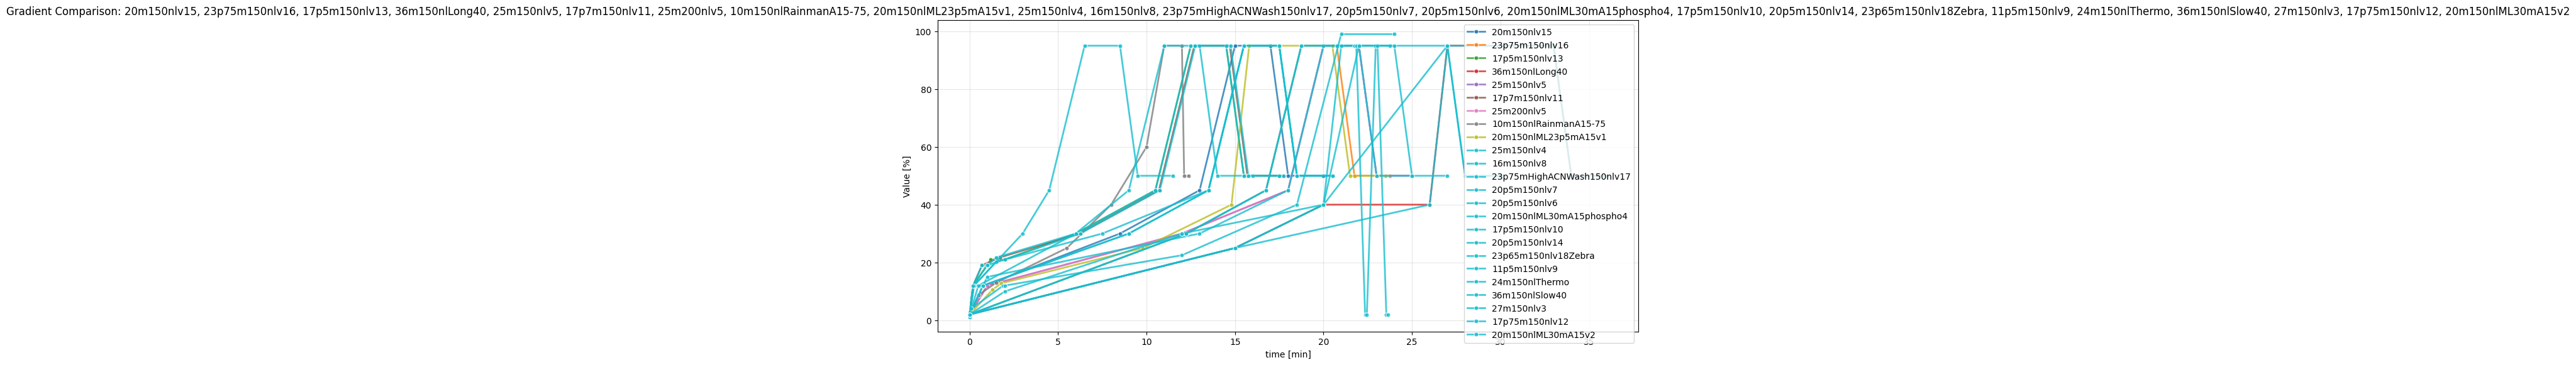

In [612]:
lccollection.plot_gradients(
                        x_col = 'time [min]',
                        y_cols = ['Neo.PumpModule.Pump.%B.Value [%]'], 
                        twin_axes=True , 
                        markers=True
)

''

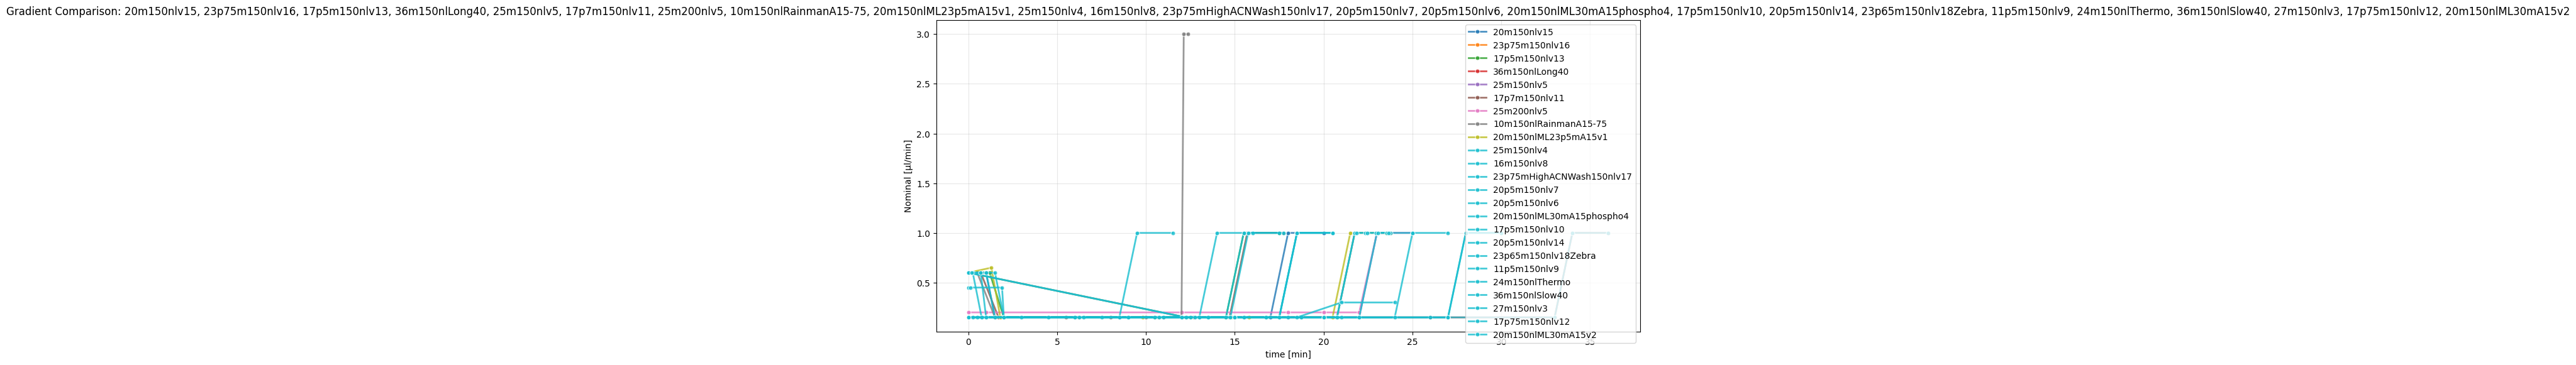

In [611]:
lccollection.plot_gradients(
                        x_col = 'time [min]',
                        y_cols = ['Neo.PumpModule.Pump.Flow.Nominal [µl/min]'], 
                        twin_axes=True , 
                        markers=True
)
, 

## MS Methods

## Load MS Methods

In [600]:
# Intialize MS method collector object
mscollection = MSMethodCollection()


In [601]:
# # Method 1: Add single method with explicit name
collection.add_method("/Users/eileen.wang/Desktop/diann/SampleData/methods/MS/DIA003.proteoscape.m")

# Method 2: Add from zip file (extracts and adds all methods inside)
mscollection.add_methods_from_folder("/Users/eileen.wang/Desktop/diann/SampleData/methods/MS/DIA015.proteoscape.m.zip")
# collection.add_methods_from_paths(["/Users/eileen.wang/Desktop/diann/SampleData/methods/MS/DIA003.proteoscape.m"], overwrite = 'ignore')
msmethod_names = '\n'.join(mscollection.methods.keys())
print(f"Loaded {len(mscollection)} methods: {msmethod_names}")


Loaded 32 methods: DIA011RT70expandedrange.proteoscape
DIA011RT70expandedrangeW83.proteoscape
DIA014.proteoscape
DIA011RT75.proteoscape
DIA011RT75expandedrange.proteoscape
DIA011RT60expandedrangeW83.proteoscape
DIA011RT50expandedrangeW83.proteoscape
DIA011RT75expandedrangeV1400.proteoscape
DIA016.proteoscape
DIA011RT75expandedrangeW83.proteoscape
DIA011RT40expandedrangeW83.proteoscape
DIA50ms003.proteoscape
DIA011V1600.proteoscape
DIA011RT70expandedrangeW63.proteoscape
DIA012.proteoscape
DIA011RT70expandedrangeW62.proteoscape
DIA011expandedrange
DIA011QC2.proteoscape
DIA011RT60expandedrange.proteoscape
DIA017.proteoscape
DIA011QC2windows.proteoscape
MHC2DIA106_DIA001im.proteoscape
DIA011.proteoscape
DIA013.proteoscape
DIA011RT60expandedrangeV1600.proteoscape
DIA015.proteoscape
DIA011RT75expandedrangeW63.proteoscape
DIA011RT70expandedrangeW82.proteoscape
DIA011RT60.proteoscape
DIA018.proteoscape
DIA011QC2v1600.proteoscape
DIA50ms007.proteoscape


### MS Meth Summary

In [602]:
mscollection['DIA011RT70expandedrange.proteoscape'].dia.windows

,Id,Type,CycleId,OneOverK0Start,OneOverK0End,IsolationMz,IsolationWidth,CollisionEnergy,WindowType,MzStart,MzEnd
0,1,0,0,NaN,NaN,NaN,NaN,None,MS1,NaN,NaN
1,2,1,1,0.86,1.30,744.115,29.55,None,MS2/DIA,729.34,758.89
2,3,1,1,0.70,0.86,383.675,128.99,None,MS2/DIA,319.18,448.17
3,4,1,2,0.91,1.30,774.360,30.94,None,MS2/DIA,758.89,789.83
4,5,1,2,0.70,0.91,469.450,42.56,None,MS2/DIA,448.17,490.73
5,6,1,3,0.93,1.30,806.090,32.52,None,MS2/DIA,789.83,822.35
6,7,1,3,0.70,0.93,507.480,33.50,None,MS2/DIA,490.73,524.23
7,8,1,4,0.95,1.30,839.850,35.00,None,MS2/DIA,822.35,857.35
8,9,1,4,0.70,0.95,540.235,32.01,None,MS2/DIA,524.23,556.24
9,10,1,5,0.96,1.30,875.200,35.70,None,MS2/DIA,857.35,893.05


In [603]:
mscollection['DIA011RT70expandedrange.proteoscape'].ms.polarity_configs

{'negative': {'default': {'Calibration_Collision_GasSupply_Set': 58.0,
   'Calibration_CurrentMethodPathName': '',
   'Calibration_Digitizer_ExtractPulsWidth': 0.0,
   'Calibration_Digitizer_ExtractTriggerTime': 155.0,
   'Calibration_FocusPreQuadrupole_SplitLens2_DutyCycle_Set': 50.0,
   'Calibration_FocusPreQuadrupole_SplitLens2_OpenTime_Set': 20.0,
   'Calibration_FocusPreTOF_Lens1_Extraction_Set': -23.5,
   'Calibration_FocusPreTOF_Lens1_PrePulseStorageTime': 15.0,
   'Calibration_FocusPreTOF_Lens1_Storage_Set': -30.0,
   'Calibration_FocusPreTOF_Lens1_TransferTime': 150.0,
   'Calibration_FocusPreTOF_Lens2_Set': 0.0,
   'Calibration_FocusPreTOF_Lens3_Set': 91.80786026200873,
   'Calibration_FocusPreTOF_Lens4_Set': 0.0,
   'Calibration_FocusPreTOF_Lens5_Set': 0.0,
   'Calibration_LastCalibrationCurrentMass': [601.9793508901306,
    1033.9875059557262,
    1333.9678111837588,
    1633.9472775662346,
    1933.9257722140976,
    2233.904284463525,
    2533.882652732354,
    2833.86004

In [604]:
mscollection['DIA011RT70expandedrange.proteoscape'].ms.instrument_params

{'Collision_ATS_QuenchTime_Set': 10,
 'Collision_EntranceFix': 1,
 'Collision_GasSupply_Set': 58.0,
 'Collision_QuenchAlways_Set': 1,
 'Collision_QuenchTime_Set': 6,
 'Digitizer_ADCCompensation': 0,
 'Digitizer_ConfigurationMode': 4,
 'Digitizer_FullScale': 316.0,
 'Digitizer_NoiseSuppressionThreshold': 7.0,
 'Digitizer_SampleIntervall': 0.2,
 'Digitizer_TriggerLevel': 1400,
 'Digitizer_VertOffset': 202.598857,
 'Digitizer_bandwidth': 0,
 'IMS_ATS_Cycle_PurgeLength': 2.0,
 'IMS_ATS_Cycle_PurgeTransferDelay': 2.0,
 'IMS_ATS_Cycle_TransferTime': 4.0,
 'IMS_Cycle_PurgeLength': 2.0,
 'IMS_Cycle_PurgeTransferDelay': 1.0,
 'IMS_Cycle_TransferTime': 2.0,
 'IMS_FunnelTunnel_T1_TrapCalculateFactor': 0.25,
 'Internal_AutotuneSingleIonIntensityFactor': 3.0,
 'MSMS_Pasef_MobilogramGridMzOverlap': 0.5,
 'MSMS_Pasef_MobilogramGridMzWidth': 2.5,
 'MSMS_Pasef_Mobilogram_Threshold': 50,
 'MSMS_Pasef_MultipletGroupingMobilityTolerance': 10,
 'MSMS_Pasef_MultipletGroupingMzTolerance': 0.025,
 'MSMS_Pasef

In [605]:
mscollection.summary_df()

,Method,TOF Detector,Capillary Exit Voltage (Pos) [V],IMS Ramp Time [ms],Focus PreTOF Transfer Time [us],Focus PreTOF PrePulse Storage [us],Ramp Rate [Hz],DIA Total Windows,DIA PASEF Cycles,DIA Windows per Cycle,DIA m/z Min,DIA m/z Max,DIA Ion Mobility Min (1/K0),DIA Ion Mobility Max (1/K0),Cycle Time [s]
0,DIA011RT70expandedrange.proteoscape,2265.0,220.0,70.0,60.0,12.0,14.271036,20,10,2,319.18,1199.9900,0.70,1.30,0.700720
1,DIA011RT70expandedrangeW83.proteoscape,2265.0,220.0,70.0,60.0,12.0,14.271036,24,8,3,318.52,1411.9995,0.65,1.45,0.560576
2,DIA014.proteoscape,2252.0,220.0,25.0,60.0,12.0,39.885131,40,20,2,319.18,1199.9900,0.70,1.30,0.501440
3,DIA011RT75.proteoscape,2265.0,220.0,75.0,60.0,12.0,13.320546,20,10,2,319.18,1199.9900,0.70,1.30,0.750720
4,DIA011RT75expandedrange.proteoscape,2265.0,220.0,75.0,60.0,12.0,13.320546,20,10,2,319.18,1199.9900,0.70,1.30,0.750720
5,DIA011RT60expandedrangeW83.proteoscape,2265.0,220.0,60.0,60.0,12.0,16.646691,24,8,3,318.52,1411.9995,0.65,1.45,0.480576
6,DIA011RT50expandedrangeW83.proteoscape,2265.0,220.0,50.0,60.0,12.0,19.971241,24,8,3,318.52,1411.9995,0.65,1.45,0.400576
7,DIA011RT75expandedrangeV1400.proteoscape,2265.0,220.0,75.0,60.0,12.0,13.320546,20,10,2,319.18,1199.9900,0.70,1.30,0.750720
8,DIA016.proteoscape,2252.0,220.0,100.0,60.0,12.0,9.992805,8,4,2,319.18,1199.9900,0.70,1.30,0.400288
9,DIA011RT75expandedrangeW83.proteoscape,2265.0,220.0,75.0,60.0,12.0,13.320546,24,8,3,318.52,1411.9995,0.65,1.45,0.600576


### Find Differences between methods

In [552]:
mscollection.get_method_summary()

AttributeError: 'MSMethodCollection' object has no attribute 'get_method_summary'

In [548]:
# finding differences between 2+ methods
diff = mscollection.find_differences(['DIA011RT60.proteoscape','DIA018.proteoscape'])
print(diff.keys())
print(f'Methods are identical: {diff["identical"]}')
diff['param_differences_df'].head()


dict_keys(['identical', 'param_differences_df', 'dia_differences_df', 'summary'])
Methods are identical: False


,DIA011RT60.proteoscape,DIA018.proteoscape
Parameter,,
Vacuum_LastCapillaryCleaningDate,2025-11-24T12:05:17-08:00,2025-08-18T09:57:05-07:00
TOF_DetectorTofSetValue,2265.0,2252.0
positive_default_IMS_CalibrationCoefficients,"[0.03084927968991898, 160.35509090775577, 15.9...","[0.001523152265349233, 165.08327143248422, 16...."
positive_default_IMS_CalibrationRampEnd,139.972162,140.502687
positive_default_IMS_CalibrationRampStart,243.402636,239.900581


In [551]:
diff['dia_differences_df']

,DIA011RT60.proteoscape,DIA018.proteoscape
Setting,,
window_count,21,13


#### Plotting differences

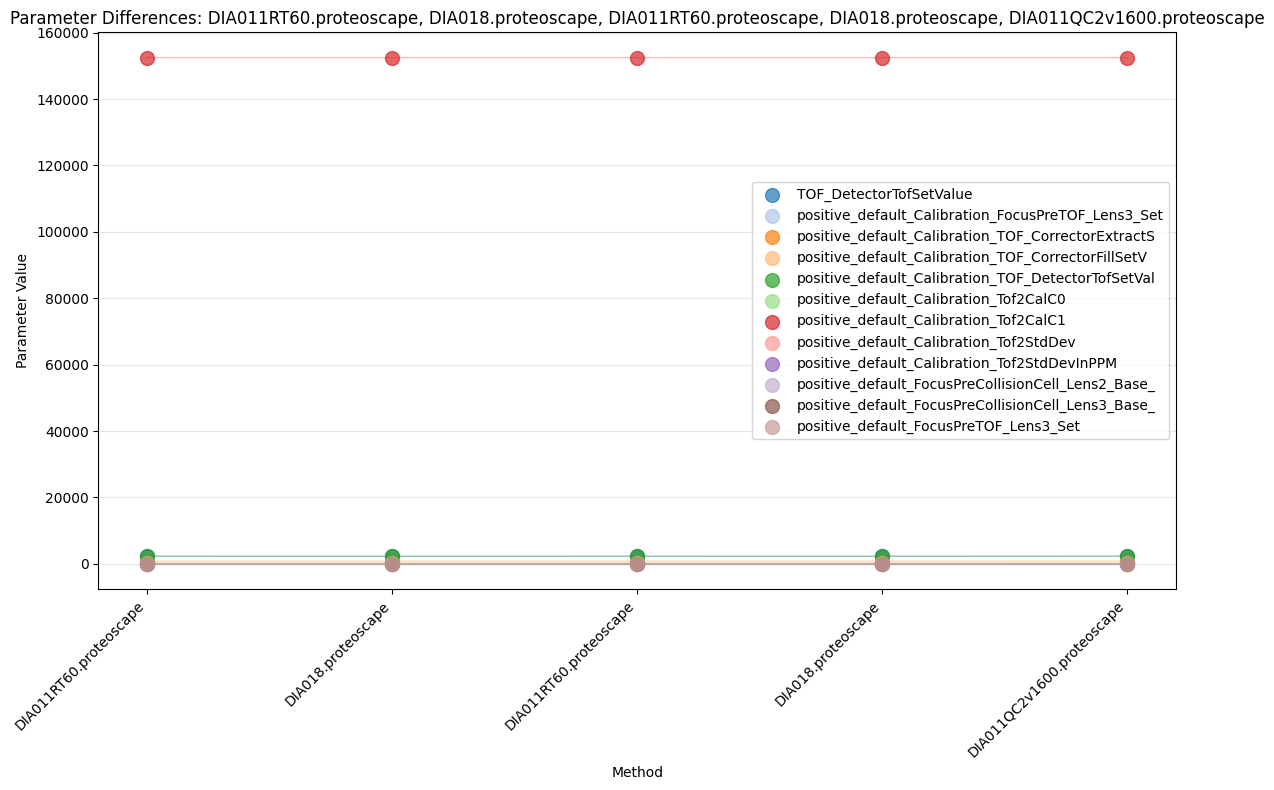

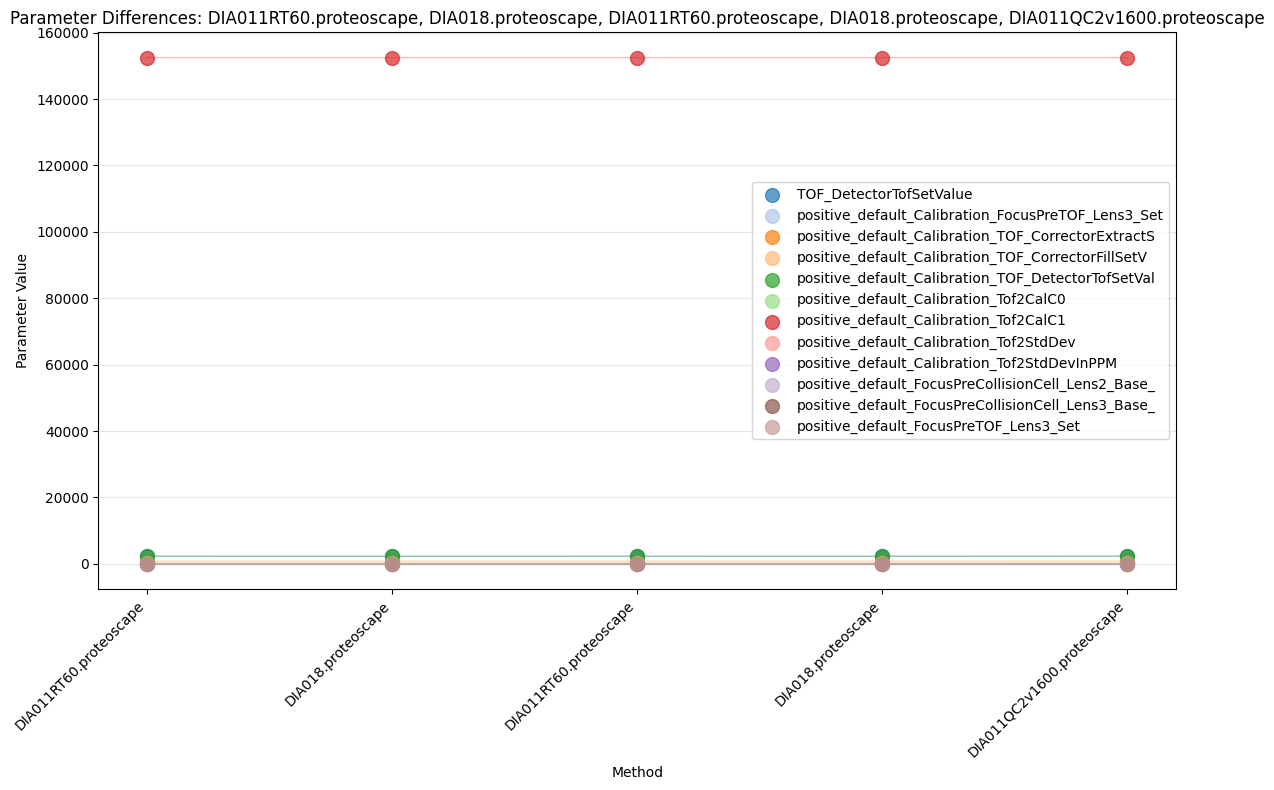

In [527]:
mscollection.plot_differences(method_names = ['DIA011RT60.proteoscape',
'DIA018.proteoscape',
'DIA011RT60.proteoscape',
'DIA018.proteoscape',
'DIA011QC2v1600.proteoscape'],
# param_names = ['TOF_DetectorTofSetValue']
)

### Plot DIA Windows

<Axes: title={'center': 'DIA Windows Overlay: DIA011RT60.proteoscape, DIA018.proteoscape'}, xlabel='m/z', ylabel='1/K0 (Ion Mobility)'>

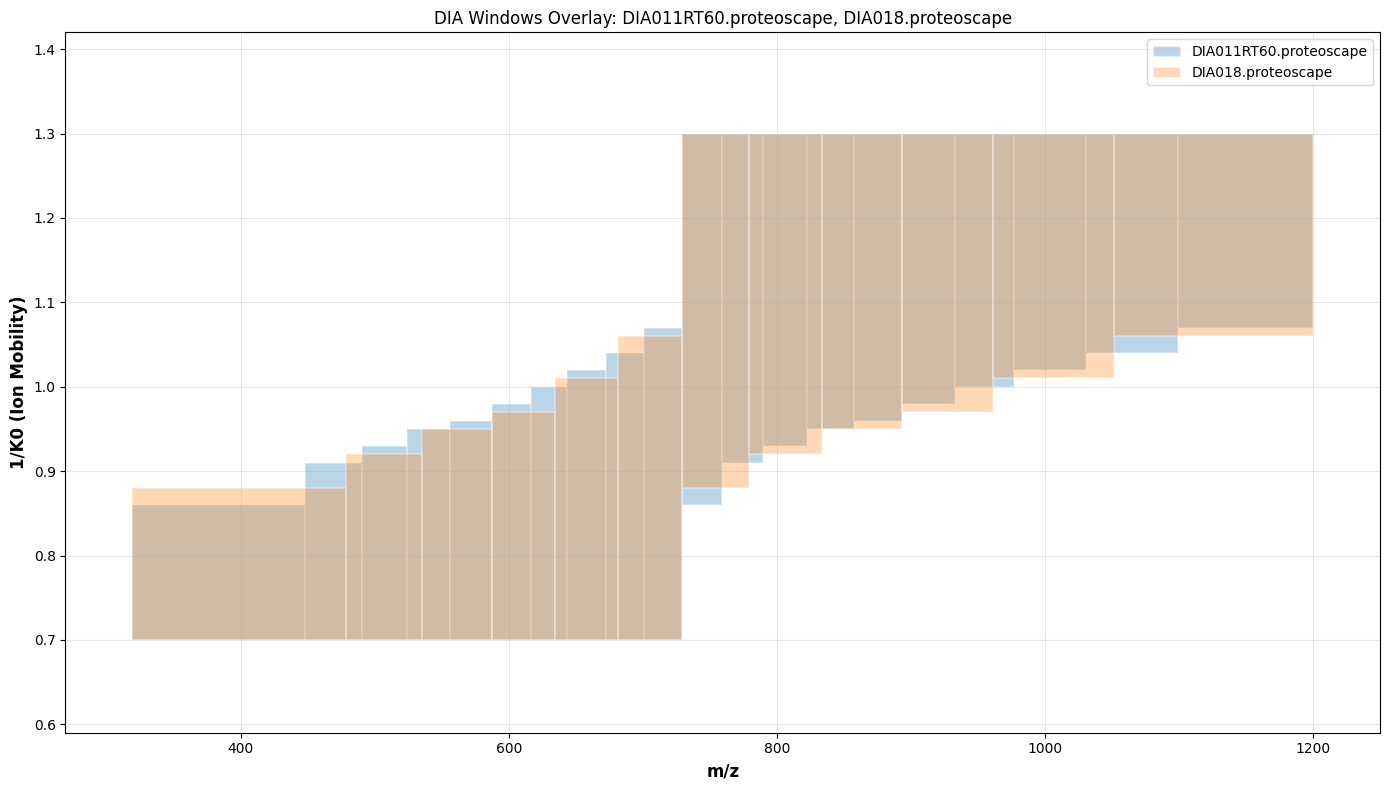

In [475]:
collection.plot_windows(['DIA011RT60.proteoscape', 'DIA018.proteoscape'], color_by_method=True,
                    alpha=0.3,
                    # edge_color='white',
                    # figsize=(14, 8),
                    show_labels=False)

## Loading Searches

In [ ]:
precursoradata = dl.load_to_adata(
        "/Users/eileen.wang/Desktop/diann/SampleData/FP/diann-output/report.tsv",
        level="precursor",
        # output_path='/Users/eileen.wang/Desktop/diann/SampleData/FP/h5ad'
    )

In [728]:
samplecollection = DiannCollection()
samplecollection.add_single_search("/Users/eileen.wang/Desktop/diann/SampleData/BPS/5bb65d07aa6a2f77f81b5e08ab034d2b/processing-run/30ea70f3-8b8e-4021-ba62-24a77d9e9b15")


Loading 30ea70f3-8b8e-4021-ba62-24a77d9e9b15 from results.tsv...
  ⚠ Note: precursor level missing some columns: All Mapped Genes, All Mapped Proteins, Averagine...
  Loading precursor level...


/Users/eileen.wang/Desktop/diann/code/anndiannloader.py:202: UserWarning: Missing columns for level 'precursor': {'Lib.Index', 'Ms1.Translated', 'Predicted.IM', 'Translated.Q.Value', 'PEP', 'All Mapped Genes', 'Mass.Evidence', 'Precursor.Translated', 'iIM', 'Averagine', 'All Mapped Proteins', 'Predicted.iIM', 'Spectrum.Similarity', 'IM', 'Precursor.Mz', 'Translated.Quality', 'Global.Q.Value'}
  warnings.warn(msg)


Loaded 82635 rows with 33/50 columns for level 'precursor'
Missing columns: {'Lib.Index', 'Ms1.Translated', 'Predicted.IM', 'Translated.Q.Value', 'PEP', 'All Mapped Genes', 'Mass.Evidence', 'Precursor.Translated', 'iIM', 'Averagine', 'All Mapped Proteins', 'Predicted.iIM', 'Spectrum.Similarity', 'IM', 'Precursor.Mz', 'Translated.Quality', 'Global.Q.Value'}
Using 'Precursor.Id' as obs_name (unique values)
Using 'File.Name' as var_name
Using 'Precursor.Quantity' as x (quantification column)


/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


[[ 16486]
 [109944]
 [ 58711]
 ...
 [208042]
 [495575]
 [203319]]
  ⚠ Note: protein level missing some columns: Global.PG.Q.Value, Lib.PG.Q.Value
  Loading protein level...


/Users/eileen.wang/Desktop/diann/code/anndiannloader.py:202: UserWarning: Missing columns for level 'protein': {'Global.PG.Q.Value', 'Lib.PG.Q.Value'}
  warnings.warn(msg)


Loaded 82635 rows with 14/16 columns for level 'protein'
Missing columns: {'Global.PG.Q.Value', 'Lib.PG.Q.Value'}
Using 'Protein.Ids' as obs_name (unique values)
Using 'File.Name' as var_name
Using 'PG.MaxLFQ' as x (quantification column)


/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


[[ 109943.9609]
 [ 164336.9375]
 [ 127506.9453]
 ...
 [4355322.    ]
 [ 747767.9375]
 [1972616.    ]]
  Loading gene level...
Loaded 82635 rows with 8/8 columns for level 'gene'
Using 'Genes' as obs_name (non-unique, will be made unique)
Using 'File.Name' as var_name
  Aggregating duplicate 'Genes' values using max()
Using 'Genes.MaxLFQ' as x (quantification column)
[[ 653645.125  ]
 [ 159122.     ]
 [2957084.75   ]
 ...
 [4355322.     ]
 [  28173.00391]
 [4355322.     ]]

Adding to collection...
  Adding precursor level...
    ✓ Shape: (82635, 1)
  Adding protein level...
    ✓ Shape: (11356, 1)
  Adding gene level...
    ✓ Shape: (7355, 1)

✓ Added sample '30ea70f3-8b8e-4021-ba62-24a77d9e9b15' to collection


/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [ ]:
samplecollection = DiannCollection()

collection.add_from_folder("/Users/eileen.wang/Desktop/diann/SampleData/BPS/5bb65d07aa6a2f77f81b5e08ab034d2b.zip", levels=["precursor", 'protein'])
    
    # Access data
    # adata = collection['sample1', 'precursor']
    # print(f"Shape: {adata.shape}")
    
    # Summary
    # summary = collection.summary_df()
    # print(summary)
    
#     # Save
#     collection.save("my_collection.pkl")

# # Load later
# collection = DiannCollection.from_file("my_collection.pkl")


Found 19 DIA-NN result files (bps format)

Loading 433db48f-c7e1-462d-8e6a-24bfebac7d75...
  ⚠ Note: precursor level missing some columns: All Mapped Genes, All Mapped Proteins, Averagine...
  Loading precursor level...


/Users/eileen.wang/Desktop/diann/code/anndiannloader.py:202: UserWarning: Missing columns for level 'precursor': {'Lib.Index', 'Ms1.Translated', 'Predicted.IM', 'Translated.Q.Value', 'PEP', 'All Mapped Genes', 'Mass.Evidence', 'Precursor.Translated', 'iIM', 'Averagine', 'All Mapped Proteins', 'Predicted.iIM', 'Spectrum.Similarity', 'IM', 'Precursor.Mz', 'Translated.Quality', 'Global.Q.Value'}
  warnings.warn(msg)


Loaded 79257 rows with 33/50 columns for level 'precursor'
Missing columns: {'Lib.Index', 'Ms1.Translated', 'Predicted.IM', 'Translated.Q.Value', 'PEP', 'All Mapped Genes', 'Mass.Evidence', 'Precursor.Translated', 'iIM', 'Averagine', 'All Mapped Proteins', 'Predicted.iIM', 'Spectrum.Similarity', 'IM', 'Precursor.Mz', 'Translated.Quality', 'Global.Q.Value'}
Using 'Precursor.Id' as obs_name (unique values)
Using 'File.Name' as var_name
Using 'Precursor.Quantity' as x (quantification column)


/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


    ✓ precursor: (79257, 1)

AnnData object with n_obs × n_vars = 79257 × 1
    obs: 'Protein.Group', 'Protein.Ids', 'Protein.Names', 'Genes', 'Modified.Sequence', 'Stripped.Sequence', 'Precursor.Id', 'Precursor.Charge', 'Sample'
    var: 'File.Name', 'search_type'
    layers: 'Precursor.Quantity', 'Precursor.Normalised', 'Proteotypic', 'iRT', 'Predicted.RT', 'Predicted.iRT', 'Q.Value', 'Quantity.Quality', 'RT', 'RT.Start', 'RT.Stop', 'Lib.Q.Value', 'Ms1.Profile.Corr', 'Ms1.Area', 'Evidence', 'CScore', 'Decoy.Evidence', 'Decoy.CScore', 'Fragment.Quant.Raw', 'Fragment.Quant.Corrected', 'Fragment.Correlations', 'MS2.Scan', 'Fragment.Info'


Loading b419b5f2-24cf-4577-a309-a8d04d7dadba...
  ⚠ Note: precursor level missing some columns: All Mapped Genes, All Mapped Proteins, Averagine...
  Loading precursor level...


...

/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


    ✓ precursor: (64376, 1)

AnnData object with n_obs × n_vars = 64376 × 1
    obs: 'Protein.Group', 'Protein.Ids', 'Protein.Names', 'Genes', 'Modified.Sequence', 'Stripped.Sequence', 'Precursor.Id', 'Precursor.Charge', 'Sample'
    var: 'File.Name', 'search_type'
    layers: 'Precursor.Quantity', 'Precursor.Normalised', 'Proteotypic', 'iRT', 'Predicted.RT', 'Predicted.iRT', 'Q.Value', 'Quantity.Quality', 'RT', 'RT.Start', 'RT.Stop', 'Lib.Q.Value', 'Ms1.Profile.Corr', 'Ms1.Area', 'Evidence', 'CScore', 'Decoy.Evidence', 'Decoy.CScore', 'Fragment.Quant.Raw', 'Fragment.Quant.Corrected', 'Fragment.Correlations', 'MS2.Scan', 'Fragment.Info'


Loading b33686f6-b65d-49be-8ce7-8fd3f9701afa...
  ⚠ Note: precursor level missing some columns: All Mapped Genes, All Mapped Proteins, Averagine...
  Loading precursor level...
Loaded 7357 rows with 33/50 columns for level 'precursor'
Missing columns: {'Lib.Index', 'Ms1.Translated', 'Predicted.IM', 'Translated.Q.Value', 'PEP', 'All Mapped Genes', 'Mas

/Users/eileen.wang/Desktop/diann/code/anndiannloader.py:202: UserWarning: Missing columns for level 'precursor': {'Lib.Index', 'Ms1.Translated', 'Predicted.IM', 'Translated.Q.Value', 'PEP', 'All Mapped Genes', 'Mass.Evidence', 'Precursor.Translated', 'iIM', 'Averagine', 'All Mapped Proteins', 'Predicted.iIM', 'Spectrum.Similarity', 'IM', 'Precursor.Mz', 'Translated.Quality', 'Global.Q.Value'}
  warnings.warn(msg)
/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


    ✓ precursor: (7357, 1)

AnnData object with n_obs × n_vars = 7357 × 1
    obs: 'Protein.Group', 'Protein.Ids', 'Protein.Names', 'Genes', 'Modified.Sequence', 'Stripped.Sequence', 'Precursor.Id', 'Precursor.Charge', 'Sample'
    var: 'File.Name', 'search_type'
    layers: 'Precursor.Quantity', 'Precursor.Normalised', 'Proteotypic', 'iRT', 'Predicted.RT', 'Predicted.iRT', 'Q.Value', 'Quantity.Quality', 'RT', 'RT.Start', 'RT.Stop', 'Lib.Q.Value', 'Ms1.Profile.Corr', 'Ms1.Area', 'Evidence', 'CScore', 'Decoy.Evidence', 'Decoy.CScore', 'Fragment.Quant.Raw', 'Fragment.Quant.Corrected', 'Fragment.Correlations', 'MS2.Scan', 'Fragment.Info'


Combining samples across levels...
  Combining 19 samples for precursor level...
    ✓ Combined shape: (932937, 19)

✓ Added 19 samples to collection


/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [709]:
collection.data['precursor'].layers['iRT']

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

In [703]:

collection.data['protein'].to_df('PG.Q.Value')

File.Name,Blank_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_23p75m150nlv16_DIA75msW83_TT0000227_B-A9_1_14628,Blank_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_23p75m150nlv16_DIA75msW83_TT0000229_B-A9_1_14630,HeLa_100pg_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_11p5150nlv9_DIA75msW83_TT0000212_B-E11_1_14613,HeLa_100pg_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_16m150nlv8_DIA60msW83_75msIMcal_TT0000213_B-E11_1_14614,HeLa_100pg_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_16m150nlv8_DIA75msW63_TT0000214_B-E11_1_14615,HeLa_100pg_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_16m150nlv8_DIA75msW83_TT0000211_B-E11_1_14612,HeLa_100pg_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_20p5m150nlv5_DIA75msW83_TT0000210_B-E11_1_14611,HeLa_100pg_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_25m150nlv5_DIA75msW83_TT0000209_B-E11_1_14610,HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p5m150nlv5_DIA75msW83_TT0000216_B-B1_1_14617,HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p75m150nlv12_DIA75msW83_TT0000219_B-B1_1_14620,HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p7m150nlv11_DIA60msW83_75msIMcal_TT0000218_B-B1_1_14619,HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p7m150nlv11_DIA75msW83_TT0000217_B-B1_1_14618,HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_20p5m150nlv5_DIA75msW83_TT0000215_B-B1_1_14616,HeLa_50ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_22p75m150nlv16_DIA75msW83_TT0000226_B-A1_1_14627,HeLa_50ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_23p65m150nlv18Zebra_DIA75msW83_TT0000230_B-A1_1_14631,HeLa_50ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_23p75mHighACNW150nlv17_DIA75msW83_TT0000228_B-A1_1_14629,HeLa_5ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_20m150nlv15_DIA75msW83_TT0000223_B-C1_1_14624,HeLa_5ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_20p5m150nlv7_DIA75msW83_TT0000224_B-C1_1_14625,HeLa_5ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_22p75m150nlv16_DIA75msW83_TT0000225_B-C1_1_14626
Protein.Ids,,,,,,,,,,,,,,,,,,,
A0A0B4J2A2;P0DN37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A0A0B4J2D5;A0A0B4J2D5-2;P0DPI2;P0DPI2-2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A0A0B4J2F0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A0A0U1RR11;P0DPI3;A0A0U1RRI6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A0A0U1RRI6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q9Y6N5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contaminant_GR78_KLULA;contaminant_GR78_SCHPO;contaminant_GR78_YEAST,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contaminant_GR78_PLAFO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
collection.data['protein'].layers['PG.Q.Value'].isna()

AttributeError: 'numpy.ndarray' object has no attribute 'isna'

In [706]:
collection.data['precursor'].to_df('iRT').isna().all()

File.Name
Blank_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_23p75m150nlv16_DIA75msW83_TT0000227_B-A9_1_14628                 True
Blank_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_23p75m150nlv16_DIA75msW83_TT0000229_B-A9_1_14630                 True
HeLa_100pg_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_11p5150nlv9_DIA75msW83_TT0000212_B-E11_1_14613              True
HeLa_100pg_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_16m150nlv8_DIA60msW83_75msIMcal_TT0000213_B-E11_1_14614     True
HeLa_100pg_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_16m150nlv8_DIA75msW63_TT0000214_B-E11_1_14615               True
HeLa_100pg_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_16m150nlv8_DIA75msW83_TT0000211_B-E11_1_14612               True
HeLa_100pg_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_20p5m150nlv5_DIA75msW83_TT0000210_B-E11_1_14611             True
HeLa_100pg_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_25m150nlv5_DIA75msW83_TT0000209_B-E11_1_14610               True
HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p5m150nlv5_DIA75msW